🤖 DecodeLabs - Project 2: Data Classification Using AI

📊 STEP 1: Loading the Iris Dataset
----------------------------------------

📋 Dataset Overview:
   • Total Samples: 150
   • Number of Features: 4
   • Number of Classes: 3
   • Classes: ['setosa' 'versicolor' 'virginica']

📋 First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

📋 Dataset Statistics:
       sepal length (cm)  sepal wi

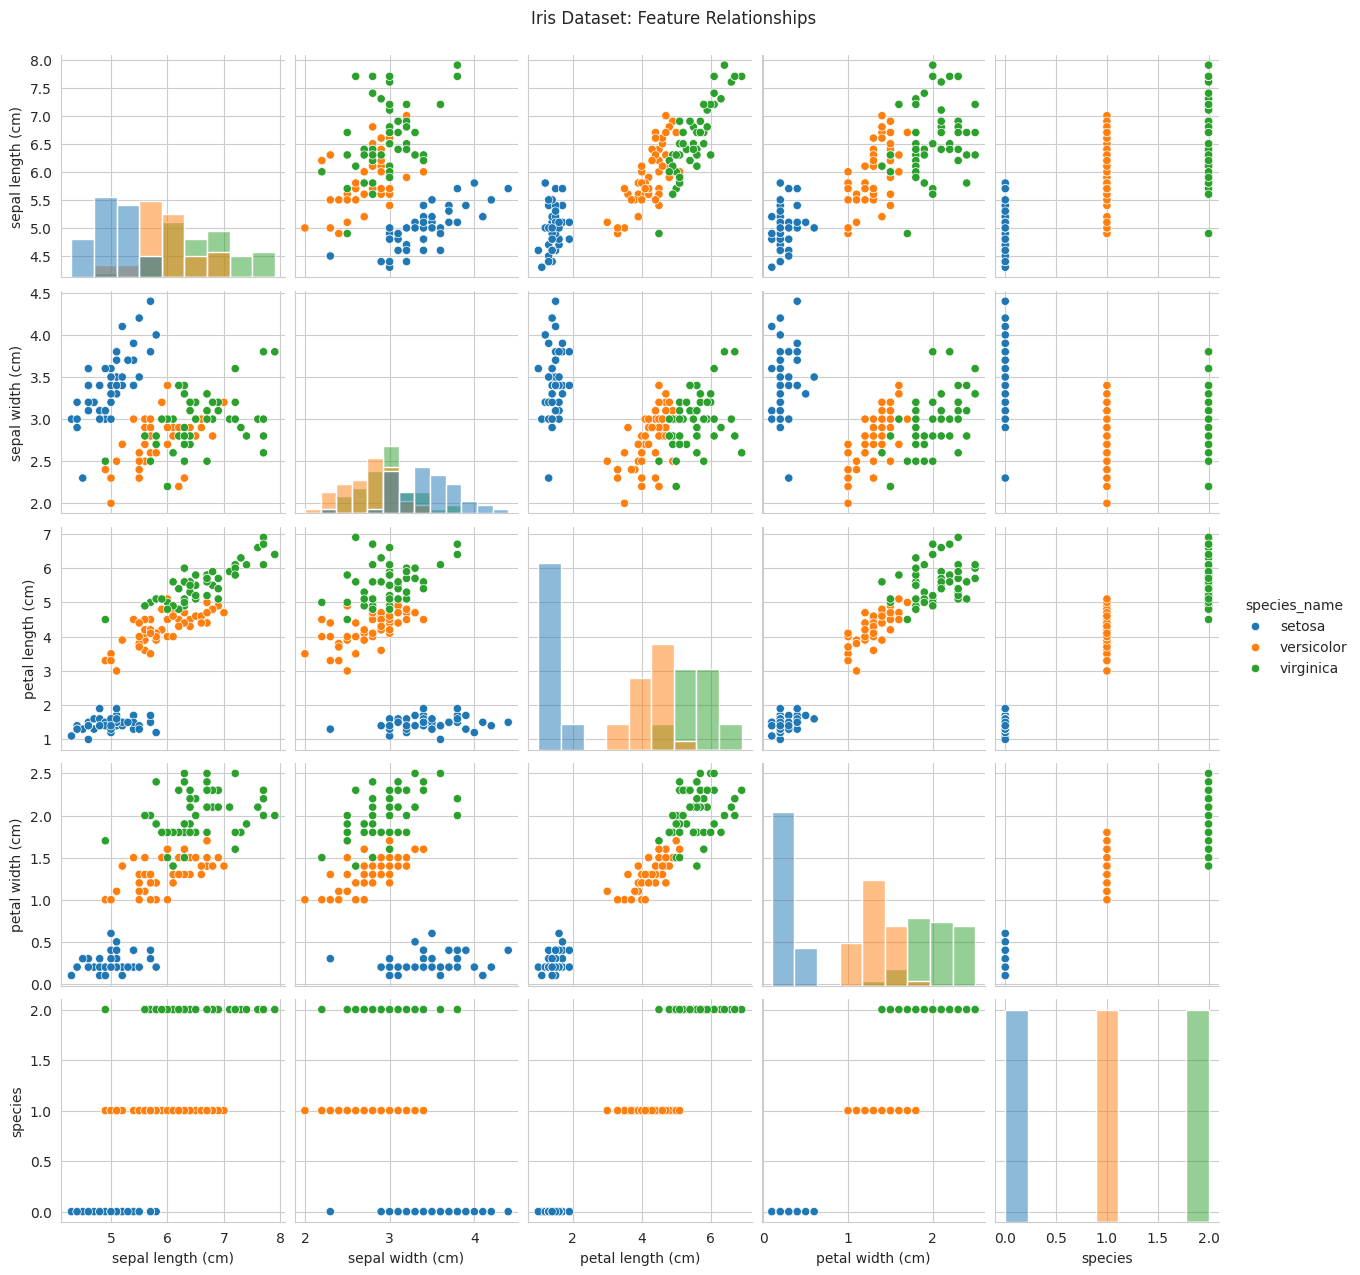

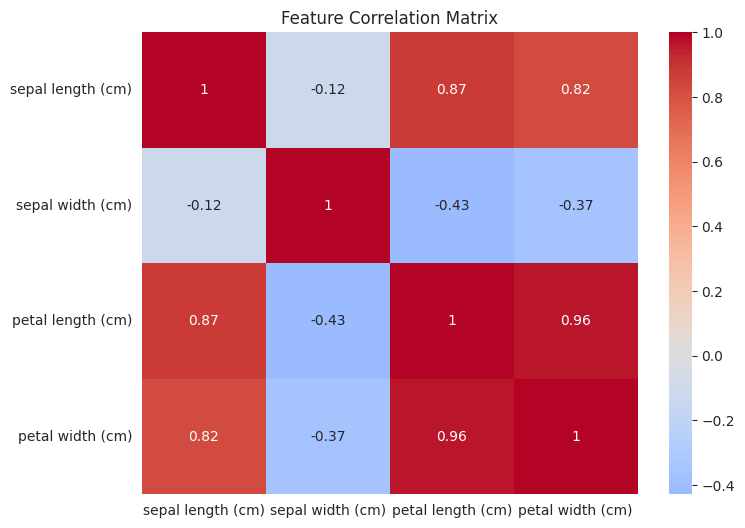


📊 STEP 3: Train-Test Split
----------------------------------------
   • Training samples: 105 (70%)
   • Testing samples: 45 (30%)
   • Training classes distribution: [35 35 35]
   • Testing classes distribution: [15 15 15]

📊 STEP 4: Feature Scaling (StandardScaler)
----------------------------------------
   • Before scaling:
     - Mean of first feature: 5.873
     - Std of first feature: 0.859

   • After scaling (Mean=0, Variance=1):
     - Mean of first feature: 0.000
     - Std of first feature: 1.000

📊 STEP 5: Training K-Nearest Neighbors (KNN)
----------------------------------------
   ✅ Model trained successfully!
   • Algorithm: K-Nearest Neighbors
   • K value: 5
   • Distance metric: minkowski

📊 STEP 6: Making Predictions
----------------------------------------
   • Predictions completed!
   • Sample predictions: [2 1 1 1 2 2 1 1 0 2]
   • Actual labels:      [2 1 2 1 2 2 1 1 0 2]

📊 STEP 7: Model Evaluation
----------------------------------------
   📈 Accuracy: 91.

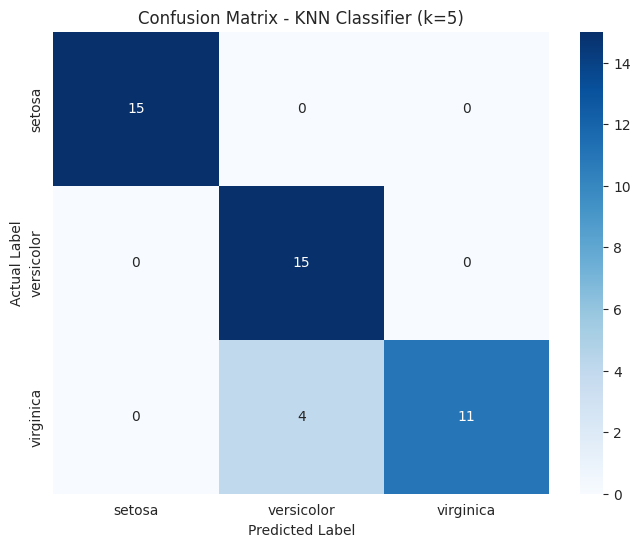


   Confusion Matrix Interpretation:
   [[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

   • Diagonal values = Correct predictions
   • Off-diagonal values = Misclassifications

📊 STEP 9: Finding the Optimal K Value
----------------------------------------


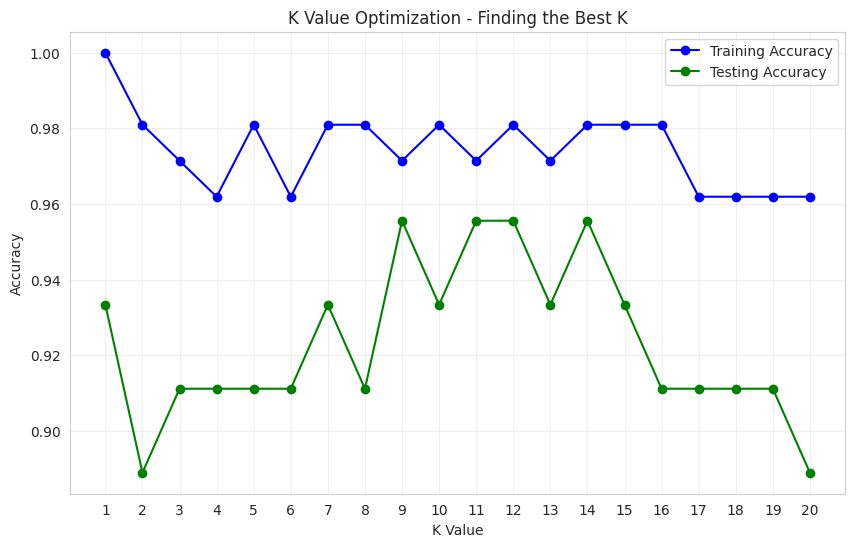


   • Best K value: 9
   • Best testing accuracy: 95.56%
   • Default K=5 accuracy: 91.11%

   💡 Tip: Try retraining with K=9 for better results!

📊 PROJECT 2 SUMMARY REPORT

✅ COMPLETED REQUIREMENTS:
   ✓ Loaded and understood Iris dataset (150 samples, 4 features, 3 classes)
   ✓ Split data into training (70%) and testing (30%)
   ✓ Applied StandardScaler for feature normalization
   ✓ Implemented K-Nearest Neighbors (KNN) classifier
   ✓ Evaluated using Confusion Matrix and F1 Score

📈 PERFORMANCE METRICS:

   • Accuracy:  91.11%
   • F1 Score:  90.95%

🔍 KEY INSIGHTS:
   • KNN works on proximity principle: similar flowers have similar features
   • Scaling is crucial because KNN uses distance calculations
   • The confusion matrix shows which species are often confused
   • Iris dataset is well-balanced, so accuracy is reliable

🎉 Congratulations! You've completed Project 2 at DecodeLabs!
💡 Next step: Try different algorithms like Decision Tree or SVM!


In [1]:
# Project 2: Data Classification Using AI
# DecodeLabs - Industrial Training Kit
# KNN Classifier on Iris Dataset

# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn imports for the ML pipeline
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("="*60)
print("🤖 DecodeLabs - Project 2: Data Classification Using AI")
print("="*60)

# ============================================
# STEP 2: LOAD AND UNDERSTAND THE DATASET
# ============================================
print("\n📊 STEP 1: Loading the Iris Dataset")
print("-"*40)

# Load the iris dataset
iris = load_iris()

# Convert to DataFrame for better understanding
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("\n📋 Dataset Overview:")
print(f"   • Total Samples: {len(df)}")
print(f"   • Number of Features: {len(iris.feature_names)}")
print(f"   • Number of Classes: {len(iris.target_names)}")
print(f"   • Classes: {iris.target_names}")

print("\n📋 First 5 rows of the dataset:")
print(df.head())

print("\n📋 Dataset Statistics:")
print(df[iris.feature_names].describe())

print("\n📋 Class Distribution (Balanced):")
print(df['species_name'].value_counts())

# ============================================
# STEP 3: VISUALIZE THE DATA (Understanding)
# ============================================
print("\n📊 STEP 2: Data Visualization")
print("-"*40)

# Pairplot to see relationships between features
fig = sns.pairplot(df, hue='species_name', diag_kind='hist')
plt.suptitle("Iris Dataset: Feature Relationships", y=1.02)
plt.show()

# Feature correlation heatmap
plt.figure(figsize=(8, 6))
correlation = df[iris.feature_names].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

# ============================================
# STEP 4: SPLIT DATA (Training 70% / Testing 30%)
# ============================================
print("\n📊 STEP 3: Train-Test Split")
print("-"*40)

X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target (species)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class balance
)

print(f"   • Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"   • Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"   • Training classes distribution: {np.bincount(y_train)}")
print(f"   • Testing classes distribution: {np.bincount(y_test)}")

# ============================================
# STEP 5: FEATURE SCALING (StandardScaler)
# ============================================
print("\n📊 STEP 4: Feature Scaling (StandardScaler)")
print("-"*40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data
X_test_scaled = scaler.transform(X_test)         # Transform test data

print("   • Before scaling:")
print(f"     - Mean of first feature: {X_train[:, 0].mean():.3f}")
print(f"     - Std of first feature: {X_train[:, 0].std():.3f}")

print("\n   • After scaling (Mean=0, Variance=1):")
print(f"     - Mean of first feature: {X_train_scaled[:, 0].mean():.3f}")
print(f"     - Std of first feature: {X_train_scaled[:, 0].std():.3f}")

# ============================================
# STEP 6: TRAIN KNN CLASSIFIER
# ============================================
print("\n📊 STEP 5: Training K-Nearest Neighbors (KNN)")
print("-"*40)

# Instantiate the model (K=5 as default)
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model (Memorize the map)
knn.fit(X_train_scaled, y_train)

print("   ✅ Model trained successfully!")
print(f"   • Algorithm: K-Nearest Neighbors")
print(f"   • K value: {knn.n_neighbors}")
print(f"   • Distance metric: {knn.metric}")

# ============================================
# STEP 7: MAKE PREDICTIONS
# ============================================
print("\n📊 STEP 6: Making Predictions")
print("-"*40)

y_pred = knn.predict(X_test_scaled)

print("   • Predictions completed!")
print(f"   • Sample predictions: {y_pred[:10]}")
print(f"   • Actual labels:      {y_test[:10]}")

# ============================================
# STEP 8: EVALUATE THE MODEL
# ============================================
print("\n📊 STEP 7: Model Evaluation")
print("-"*40)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"   📈 Accuracy: {accuracy * 100:.2f}%")

# F1 Score (Macro average - good for balanced datasets)
f1 = f1_score(y_test, y_pred, average='macro')
print(f"   📈 F1 Score (Macro): {f1 * 100:.2f}%")

# Classification Report
print("\n   📋 Detailed Classification Report:")
print("   " + "-"*35)
report = classification_report(y_test, y_pred, target_names=iris.target_names)
for line in report.split('\n'):
    print(f"   {line}")

# ============================================
# STEP 9: CONFUSION MATRIX
# ============================================
print("\n📊 STEP 8: Confusion Matrix")
print("-"*40)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN Classifier (k=5)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n   Confusion Matrix Interpretation:")
print(f"   {cm}")
print("\n   • Diagonal values = Correct predictions")
print("   • Off-diagonal values = Misclassifications")

# ============================================
# STEP 10: FINDING THE BEST K VALUE (Tuning)
# ============================================
print("\n📊 STEP 9: Finding the Optimal K Value")
print("-"*40)

k_values = range(1, 21)
test_scores = []
train_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    train_scores.append(knn_temp.score(X_train_scaled, y_train))
    test_scores.append(knn_temp.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Training Accuracy', color='blue')
plt.plot(k_values, test_scores, 'o-', label='Testing Accuracy', color='green')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value Optimization - Finding the Best K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(test_scores)]
best_accuracy = max(test_scores)

print(f"\n   • Best K value: {best_k}")
print(f"   • Best testing accuracy: {best_accuracy * 100:.2f}%")
print(f"   • Default K=5 accuracy: {accuracy * 100:.2f}%")

if best_k != 5:
    print(f"\n   💡 Tip: Try retraining with K={best_k} for better results!")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("📊 PROJECT 2 SUMMARY REPORT")
print("="*60)

print("""
✅ COMPLETED REQUIREMENTS:
   ✓ Loaded and understood Iris dataset (150 samples, 4 features, 3 classes)
   ✓ Split data into training (70%) and testing (30%)
   ✓ Applied StandardScaler for feature normalization
   ✓ Implemented K-Nearest Neighbors (KNN) classifier
   ✓ Evaluated using Confusion Matrix and F1 Score

📈 PERFORMANCE METRICS:
""")
print(f"   • Accuracy:  {accuracy * 100:.2f}%")
print(f"   • F1 Score:  {f1 * 100:.2f}%")

print("""
🔍 KEY INSIGHTS:
   • KNN works on proximity principle: similar flowers have similar features
   • Scaling is crucial because KNN uses distance calculations
   • The confusion matrix shows which species are often confused
   • Iris dataset is well-balanced, so accuracy is reliable
""")

print("="*60)
print("🎉 Congratulations! You've completed Project 2 at DecodeLabs!")
print("💡 Next step: Try different algorithms like Decision Tree or SVM!")
print("="*60)


🔬 EXPERIMENT 1: Testing Different K Values

📊 Testing K values: [1, 3, 5, 7, 9, 11, 13, 15]
----------------------------------------
K =  1 → Accuracy: 93.33% | F1 Score: 93.27%
K =  3 → Accuracy: 91.11% | F1 Score: 90.95%
K =  5 → Accuracy: 91.11% | F1 Score: 90.95%
K =  7 → Accuracy: 93.33% | F1 Score: 93.27%
K =  9 → Accuracy: 95.56% | F1 Score: 95.54%
K = 11 → Accuracy: 95.56% | F1 Score: 95.54%
K = 13 → Accuracy: 93.33% | F1 Score: 93.33%
K = 15 → Accuracy: 93.33% | F1 Score: 93.33%

🏆 BEST K VALUE: 9
   Best Accuracy: 95.56%


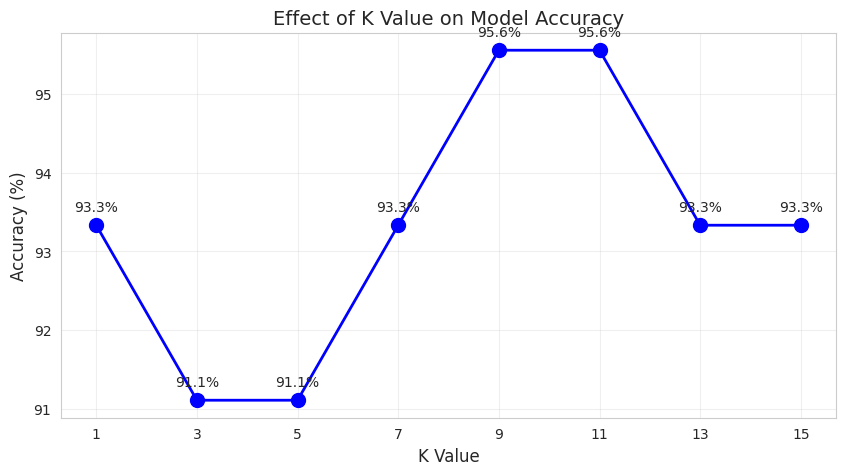

In [2]:
# EXPERIMENT 1: Finding the Best K Value
# Copy this entire block into a new cell and run

print("\n" + "="*60)
print("🔬 EXPERIMENT 1: Testing Different K Values")
print("="*60)

# List of K values to test
k_values_to_test = [1, 3, 5, 7, 9, 11, 13, 15]

print("\n📊 Testing K values:", k_values_to_test)
print("-"*40)

results = []

for k in k_values_to_test:
    # Create KNN with this k value
    knn_test = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn_test.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_test = knn_test.predict(X_test_scaled)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='macro')

    results.append({'k': k, 'accuracy': acc, 'f1': f1})

    print(f"K = {k:2} → Accuracy: {acc*100:.2f}% | F1 Score: {f1*100:.2f}%")

# Find the best k
best_result = max(results, key=lambda x: x['accuracy'])
print("\n" + "="*40)
print(f"🏆 BEST K VALUE: {best_result['k']}")
print(f"   Best Accuracy: {best_result['accuracy']*100:.2f}%")
print("="*40)

# Visual comparison
import matplotlib.pyplot as plt

k_vals = [r['k'] for r in results]
acc_vals = [r['accuracy']*100 for r in results]

plt.figure(figsize=(10, 5))
plt.plot(k_vals, acc_vals, 'bo-', linewidth=2, markersize=10)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Effect of K Value on Model Accuracy', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_vals)
for i, (k, acc) in enumerate(zip(k_vals, acc_vals)):
    plt.annotate(f'{acc:.1f}%', (k, acc), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()


🔬 EXPERIMENT 2: Comparing Different Algorithms

📊 Training and comparing all algorithms...
--------------------------------------------------
1. KNN (k=5)              ███████████████████████████░░░ 91.11%
2. Decision Tree          ███████████████████████████░░░ 91.11%
3. SVM (RBF)              ████████████████████████████░░ 93.33%
4. Random Forest          ██████████████████████████░░░░ 88.89%
5. Gradient Boosting      ████████████████████████████░░ 93.33%
6. Naive Bayes            ███████████████████████████░░░ 91.11%
7. Logistic Regression    ███████████████████████████░░░ 91.11%

🏆 RANKINGS (Best to Worst):
1. 3. SVM (RBF)              → 93.33%
2. 5. Gradient Boosting      → 93.33%
3. 1. KNN (k=5)              → 91.11%
4. 2. Decision Tree          → 91.11%
5. 6. Naive Bayes            → 91.11%
6. 7. Logistic Regression    → 91.11%
7. 4. Random Forest          → 88.89%


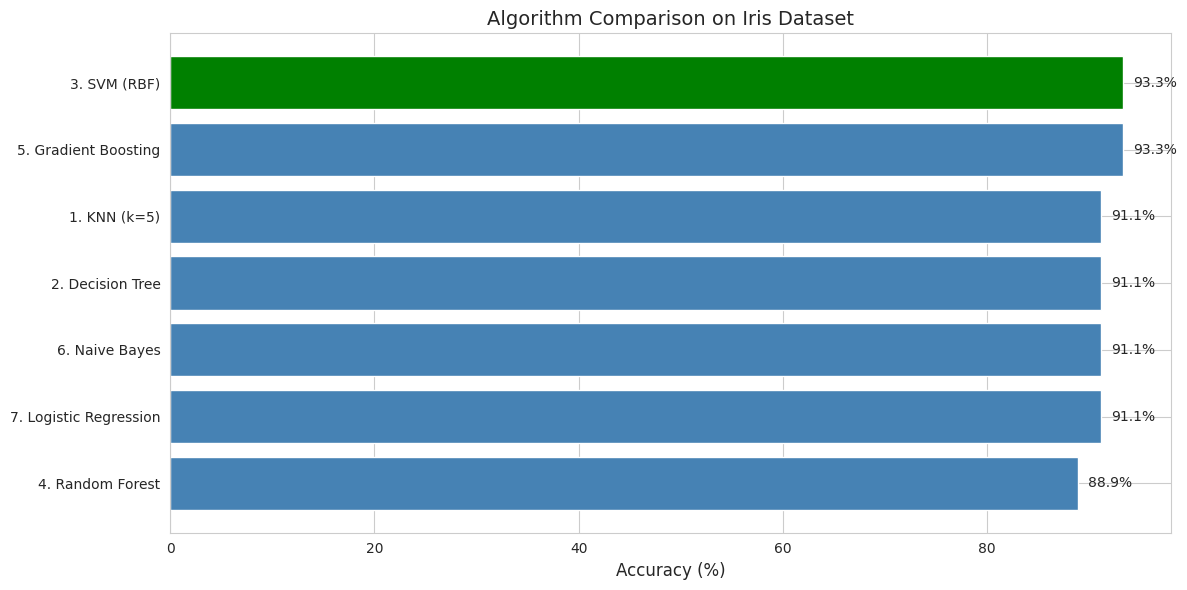


💡 INSIGHT: The best algorithm depends on your dataset!
   For Iris, most algorithms work well because the data is clean and balanced.


In [3]:
# EXPERIMENT 2: Comparing Multiple Algorithms
# Copy this entire block into a new cell and run

print("\n" + "="*60)
print("🔬 EXPERIMENT 2: Comparing Different Algorithms")
print("="*60)

# Import additional algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Dictionary of algorithms to test
algorithms = {
    '1. KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    '2. Decision Tree': DecisionTreeClassifier(random_state=42),
    '3. SVM (RBF)': SVC(random_state=42),
    '4. Random Forest': RandomForestClassifier(random_state=42),
    '5. Gradient Boosting': GradientBoostingClassifier(random_state=42),
    '6. Naive Bayes': GaussianNB(),
    '7. Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

print("\n📊 Training and comparing all algorithms...")
print("-"*50)

comparison_results = []

for name, model in algorithms.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred_temp = model.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp, average='macro')

    comparison_results.append({'algorithm': name, 'accuracy': acc, 'f1': f1})

    # Show progress with visual indicator
    bar_length = int(acc * 30)
    bar = '█' * bar_length + '░' * (30 - bar_length)
    print(f"{name:25} {bar} {acc*100:5.2f}%")

# Sort by accuracy
comparison_results.sort(key=lambda x: x['accuracy'], reverse=True)

print("\n" + "="*50)
print("🏆 RANKINGS (Best to Worst):")
print("="*50)
for i, result in enumerate(comparison_results, 1):
    print(f"{i}. {result['algorithm']:25} → {result['accuracy']*100:.2f}%")

# Visual comparison
plt.figure(figsize=(12, 6))
names = [r['algorithm'] for r in comparison_results]
accs = [r['accuracy']*100 for r in comparison_results]
colors = ['green' if i == 0 else 'steelblue' for i in range(len(names))]

plt.barh(names, accs, color=colors)
plt.xlabel('Accuracy (%)', fontsize=12)
plt.title('Algorithm Comparison on Iris Dataset', fontsize=14)
plt.gca().invert_yaxis()
for i, (name, acc) in enumerate(zip(names, accs)):
    plt.text(acc + 1, i, f'{acc:.1f}%', va='center')
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: The best algorithm depends on your dataset!")
print("   For Iris, most algorithms work well because the data is clean and balanced.")


🔬 EXPERIMENT 3: Detailed K Value Analysis (K = 1 to 20)

📊 Calculating accuracies for K = 1 to 20...
----------------------------------------
K =  1 → Train: 100.00% | Test: 93.33%
K =  5 → Train: 98.10% | Test: 91.11%
K = 10 → Train: 98.10% | Test: 93.33%
K = 15 → Train: 98.10% | Test: 93.33%
K = 20 → Train: 96.19% | Test: 88.89%

🏆 OPTIMAL K VALUE: 9
   Best Test Accuracy: 95.56%


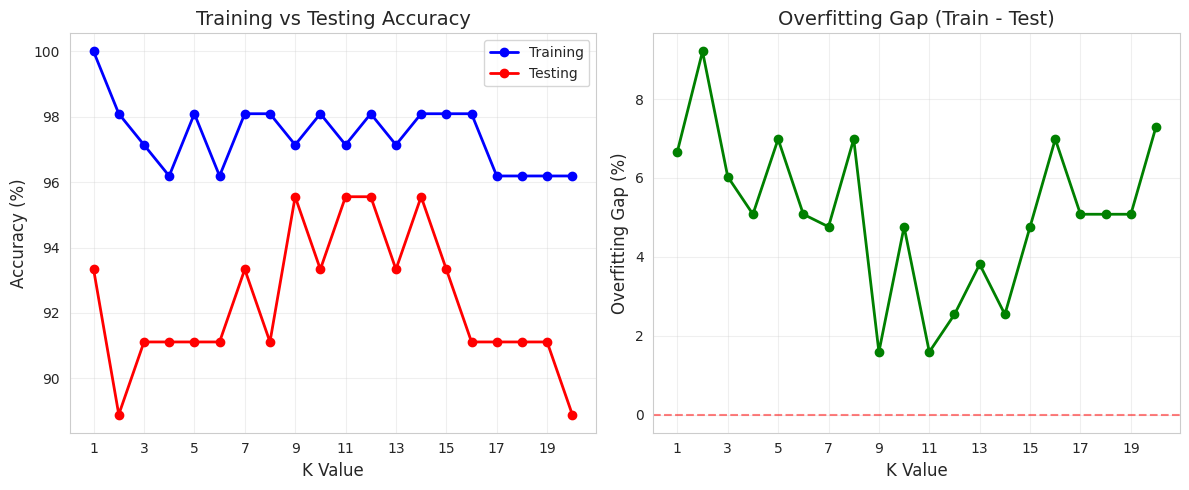


💡 INTERPRETATION:
   • Small K (1-3): High training accuracy, lower test accuracy → OVERFITTING
   • Large K (15-20): Lower overall accuracy → UNDERFITTING
   • Best K (9): Best balance between underfitting and overfitting


In [4]:
# EXPERIMENT 3: Detailed K Value Analysis (K from 1 to 20)
# Copy this entire block into a new cell and run

print("\n" + "="*60)
print("🔬 EXPERIMENT 3: Detailed K Value Analysis (K = 1 to 20)")
print("="*60)

k_range = range(1, 21)
train_scores = []
test_scores = []

print("\n📊 Calculating accuracies for K = 1 to 20...")
print("-"*40)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)

    train_acc = knn_temp.score(X_train_scaled, y_train)
    test_acc = knn_temp.score(X_test_scaled, y_test)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    # Print every 5th value to keep output clean
    if k % 5 == 0 or k == 1:
        print(f"K = {k:2} → Train: {train_acc*100:.2f}% | Test: {test_acc*100:.2f}%")

# Find best K
best_k = k_range[test_scores.index(max(test_scores))]
best_test_acc = max(test_scores)

print("\n" + "="*40)
print(f"🏆 OPTIMAL K VALUE: {best_k}")
print(f"   Best Test Accuracy: {best_test_acc*100:.2f}%")
print("="*40)

# Plot training vs testing accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, [acc*100 for acc in train_scores], 'bo-', label='Training', linewidth=2)
plt.plot(k_range, [acc*100 for acc in test_scores], 'ro-', label='Testing', linewidth=2)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training vs Testing Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_range[::2])

plt.subplot(1, 2, 2)
plt.plot(k_range, [(train_scores[i] - test_scores[i])*100 for i in range(len(k_range))], 'go-', linewidth=2)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Overfitting Gap (%)', fontsize=12)
plt.title('Overfitting Gap (Train - Test)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.xticks(k_range[::2])

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETATION:")
print("   • Small K (1-3): High training accuracy, lower test accuracy → OVERFITTING")
print("   • Large K (15-20): Lower overall accuracy → UNDERFITTING")
print(f"   • Best K ({best_k}): Best balance between underfitting and overfitting")

In [5]:
# EXPERIMENT 4: Test the Model with Custom Flower Measurements
# Copy this entire block into a new cell and run

print("\n" + "="*60)
print("🔬 EXPERIMENT 4: Testing with Custom Data")
print("="*60)

# Create 3 new unknown flowers to classify
unknown_flowers = [
    [5.1, 3.5, 1.4, 0.2],   # Looks like Setosa
    [6.5, 3.0, 5.2, 2.0],   # Looks like Virginica
    [5.9, 3.0, 4.2, 1.5],   # Looks like Versicolor
    [4.8, 3.0, 1.4, 0.3],   # Small flower
    [7.0, 3.2, 4.7, 1.4],   # Medium-large flower
]

print("\n📊 Testing unknown flowers:")
print("-"*50)

# Scale the new data using the SAME scaler
unknown_scaled = scaler.transform(unknown_flowers)

# Make predictions
predictions = knn.predict(unknown_scaled)
probabilities = knn.predict_proba(unknown_scaled)

for i, flower in enumerate(unknown_flowers):
    species = iris.target_names[predictions[i]]
    confidence = max(probabilities[i]) * 100

    print(f"\n🌸 Flower {i+1}: {flower}")
    print(f"   → Predicted: {species.upper()}")
    print(f"   → Confidence: {confidence:.1f}%")

    # Show probability distribution
    print(f"   → Probabilities: ", end="")
    for j, species_name in enumerate(iris.target_names):
        print(f"{species_name}: {probabilities[i][j]*100:.1f}%", end="  ")
    print()

# Let user test their own flower
print("\n" + "="*50)
print("🎮 TRY YOUR OWN FLOWER!")
print("="*50)

try:
    print("\nEnter your own flower measurements:")
    sl = float(input("   Sepal Length (cm): "))
    sw = float(input("   Sepal Width (cm): "))
    pl = float(input("   Petal Length (cm): "))
    pw = float(input("   Petal Width (cm): "))

    custom_flower = scaler.transform([[sl, sw, pl, pw]])
    custom_pred = knn.predict(custom_flower)
    custom_proba = knn.predict_proba(custom_flower)

    print(f"\n🌺 Your flower is: {iris.target_names[custom_pred[0]].upper()}")
    print(f"   Confidence: {max(custom_proba[0])*100:.1f}%")

except ValueError:
    print("   Please enter numbers only next time!")
except:
    print("   Skipping custom input...")


🔬 EXPERIMENT 4: Testing with Custom Data

📊 Testing unknown flowers:
--------------------------------------------------

🌸 Flower 1: [5.1, 3.5, 1.4, 0.2]
   → Predicted: SETOSA
   → Confidence: 100.0%
   → Probabilities: setosa: 100.0%  versicolor: 0.0%  virginica: 0.0%  

🌸 Flower 2: [6.5, 3.0, 5.2, 2.0]
   → Predicted: VIRGINICA
   → Confidence: 100.0%
   → Probabilities: setosa: 0.0%  versicolor: 0.0%  virginica: 100.0%  

🌸 Flower 3: [5.9, 3.0, 4.2, 1.5]
   → Predicted: VERSICOLOR
   → Confidence: 100.0%
   → Probabilities: setosa: 0.0%  versicolor: 100.0%  virginica: 0.0%  

🌸 Flower 4: [4.8, 3.0, 1.4, 0.3]
   → Predicted: SETOSA
   → Confidence: 100.0%
   → Probabilities: setosa: 100.0%  versicolor: 0.0%  virginica: 0.0%  

🌸 Flower 5: [7.0, 3.2, 4.7, 1.4]
   → Predicted: VERSICOLOR
   → Confidence: 80.0%
   → Probabilities: setosa: 0.0%  versicolor: 80.0%  virginica: 20.0%  

🎮 TRY YOUR OWN FLOWER!

Enter your own flower measurements:
   Sepal Length (cm): 6
   Sepal Width (cm)